# 📊 HR Analytics Project -Notebook 2: Exploratory Data Analysis

**Project:** HR Analytics: Workforce Intelligence Dashboard  
**Author:** Alex Lim  
**Last Updated:** 31 January 2026

---

## 📌 Purpose of This Notebook

Exploratory Data Analysis (EDA) is the process of **asking business questions and answering them with data**.
This is the most important stage for a People Analytics professional -it turns raw numbers into HR insights.

We answer **8 business questions** across all four HR domains:

| # | Business Question | Domain |
|---|-------------------|--------|
| Q1 | What does our overall workforce look like? | Workforce |
| Q2 | Which departments have the highest attrition? | Attrition |
| Q3 | Why are employees leaving? | Attrition |
| Q4 | Do senior employees stay longer? | Retention |
| Q5 | Which recruitment source is fastest and most popular? | Recruitment |
| Q6 | Does training investment drive better performance? | L&D |
| Q7 | How does salary vary across APAC markets? | Compensation |
| Q8 | Is our workforce diverse at senior levels? | Diversity |

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Chart style: clean and professional ─────────────────────
COLORS = {
    'primary':   '#2C3E7A',
    'secondary': '#3AAFB9',
    'accent':    '#F4A261',
    'danger':    '#E63946',
    'success':   '#2A9D8F',
}
PALETTE_DEPT = ['#2C3E7A','#3AAFB9','#F4A261','#E63946','#2A9D8F','#E9C46A','#A8DADC']

sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

# Load the cleaned dataset
df = pd.read_csv('../data/cleaned/hr_data_cleaned.csv')
print(f'✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')

✅ Dataset loaded: 1000 rows × 41 columns


---
## 2. Dataset Overview

Before diving into questions, we always run `describe()` and `value_counts()` to get a feel for the data.
Think of this as reading the room before starting a conversation.

In [2]:
# describe() gives summary statistics for all numeric columns
# This immediately shows us the range, average, and spread of each number
df[['Age','Tenure_Years','Annual_Salary_USD',
    'Performance_Rating','Training_Hours_Year']].describe().round(1)

,Age,Tenure_Years,Annual_Salary_USD,Performance_Rating,Training_Hours_Year
count,1000.0,1000.0,1000.0,1000.0,960.0
mean,38.4,4.3,57521.2,3.5,40.6
std,9.4,2.3,37345.2,1.0,20.8
min,23.0,0.0,7572.0,1.0,0.5
25%,30.0,2.6,26724.0,3.0,23.6
50%,38.0,4.3,48936.0,3.0,39.7
75%,47.0,5.9,81258.0,4.0,57.3
max,54.0,10.0,181212.0,5.0,79.9


In [3]:
# value_counts() for key categorical columns
print('Employment Status:')
print(df['Employment_Status'].value_counts())
print('\nGrade Level:')
print(df['Grade_Level'].value_counts().sort_index())
print('\nEmployment Type:')
print(df['Employment_Type'].value_counts())

Employment Status:
Employment_Status
Active        796
Resigned      127
Terminated     77
Name: count, dtype: int64

Grade Level:
Grade_Level
G1    152
G2    248
G3    262
G4    185
G5     97
G6     56
Name: count, dtype: int64

Employment Type:
Employment_Type
Full-Time     713
Contractor    179
Intern         72
Expat          36
Name: count, dtype: int64


---
## Q1: What Does Our Workforce Look Like?

**Business context:** Before any deeper analysis, HR leadership needs a snapshot of how many people do we have, where are they, and what is our active headcount vs attrition?

We start with KPI numbers, then visualise headcount by country and department.

In [4]:
# ── Key KPI Numbers ───────────────────────────────────────────
total        = len(df)
active       = (df['Employment_Status'] == 'Active').sum()
attrition_rt = round(df['Attrition_Flag'].mean() * 100, 1)
avg_age      = round(df['Age'].mean(), 1)
avg_tenure   = round(df['Tenure_Years'].mean(), 1)
avg_sal      = round(df['Annual_Salary_USD'].mean())

print('┌─────────────────────────────────────────┐')
print('│       WORKFORCE KPI SNAPSHOT            │')
print('├─────────────────────────────────────────┤')
print(f'│  Total headcount     : {total:<17}│')
print(f'│  Active employees    : {active:<17}│')
print(f'│  Attrition rate      : {attrition_rt}%{"":12}│')
print(f'│  Average age         : {avg_age} years{"":7}│')
print(f'│  Average tenure      : {avg_tenure} years{"":8}│')
print(f'│  Avg annual salary   : USD {avg_sal:,}{"":7}│')
print('└─────────────────────────────────────────┘')

┌─────────────────────────────────────────┐
│       WORKFORCE KPI SNAPSHOT            │
├─────────────────────────────────────────┤
│  Total headcount     : 1000             │
│  Active employees    : 796              │
│  Attrition rate      : 20.4%            │
│  Average age         : 38.4 years       │
│  Average tenure      : 4.3 years        │
│  Avg annual salary   : USD 57,521       │
└─────────────────────────────────────────┘


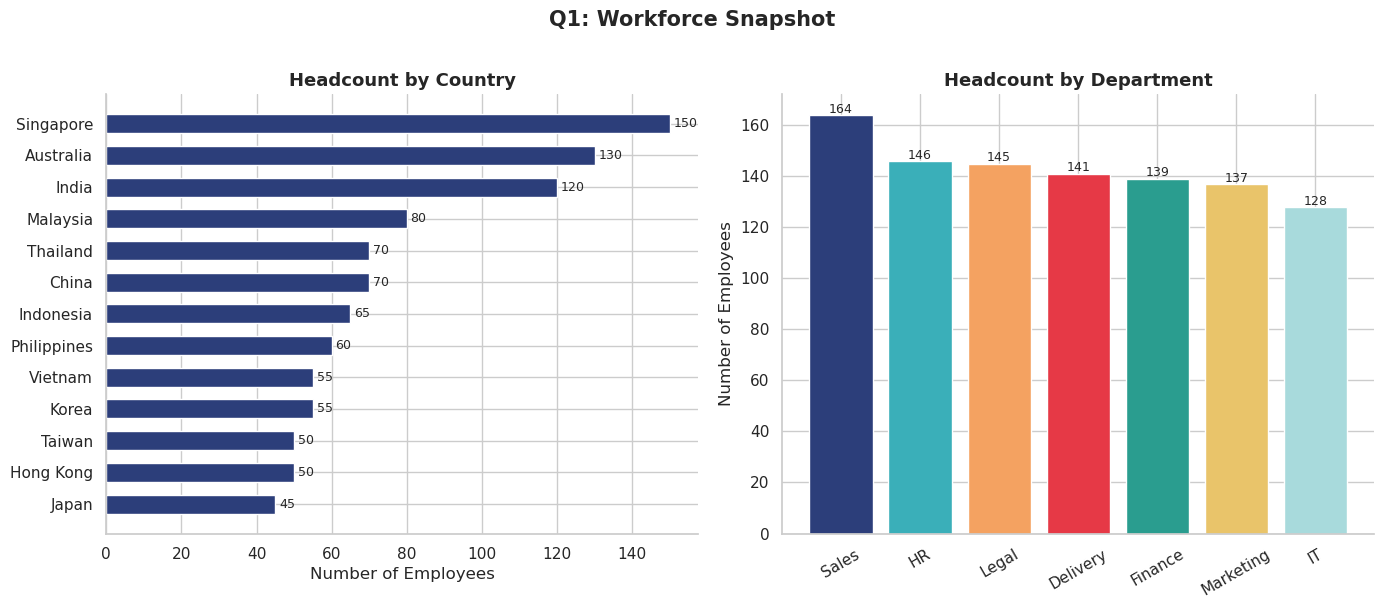

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Q1: Workforce Snapshot', fontsize=15, fontweight='bold', y=1.01)

# Headcount by Country
country_hc = df.groupby('Country').size().sort_values(ascending=True)
bars = axes[0].barh(country_hc.index, country_hc.values,
                    color=COLORS['primary'], edgecolor='white', height=0.6)
axes[0].set_title('Headcount by Country')
axes[0].set_xlabel('Number of Employees')
for bar, val in zip(bars, country_hc.values):
    axes[0].text(val+1, bar.get_y()+bar.get_height()/2,
                 str(val), va='center', fontsize=9)

# Headcount by Department
dept_hc = df.groupby('Department').size().sort_values(ascending=False)
bars2 = axes[1].bar(dept_hc.index, dept_hc.values,
                    color=PALETTE_DEPT[:len(dept_hc)], edgecolor='white')
axes[1].set_title('Headcount by Department')
axes[1].set_ylabel('Number of Employees')
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars2, dept_hc.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+1,
                 str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/q1_workforce_snapshot.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Insight - Q1
> **Singapore is our largest market (150 headcount), followed by Australia (130) and India (120)** consistent with a tech company establishing APAC regional HQ in Singapore. Sales is our largest function, while IT has the smallest headcount despite being a tech company, which may indicate heavy use of contractors or outsourcing.

---
## Q2: Which Departments Have the Highest Attrition?

**Business context:** Attrition is expensive. Replacing one employee typically costs 50–200% of their annual salary.
Identifying which departments lose the most people helps HR prioritise retention interventions.

We use `groupby()` to calculate attrition rate per department.

In [6]:
# groupby() splits the data by department, then agg() calculates multiple metrics at once
dept_attr = (df.groupby('Department')
               .agg(Total=('Employee_ID', 'count'),
                    Left=('Attrition_Flag', 'sum'))
               .assign(Attrition_Rate=lambda x: (x['Left']/x['Total']*100).round(1))
               .sort_values('Attrition_Rate', ascending=False))

print('Attrition by Department:')
print(dept_attr.to_string())
print(f'\nCompany average: {attrition_rt}%')

Attrition by Department:
            Total  Left  Attrition_Rate
Department                             
Delivery      141    37            26.2
Legal         145    33            22.8
Sales         164    35            21.3
HR            146    31            21.2
Finance       139    25            18.0
Marketing     137    23            16.8
IT            128    20            15.6

Company average: 20.4%


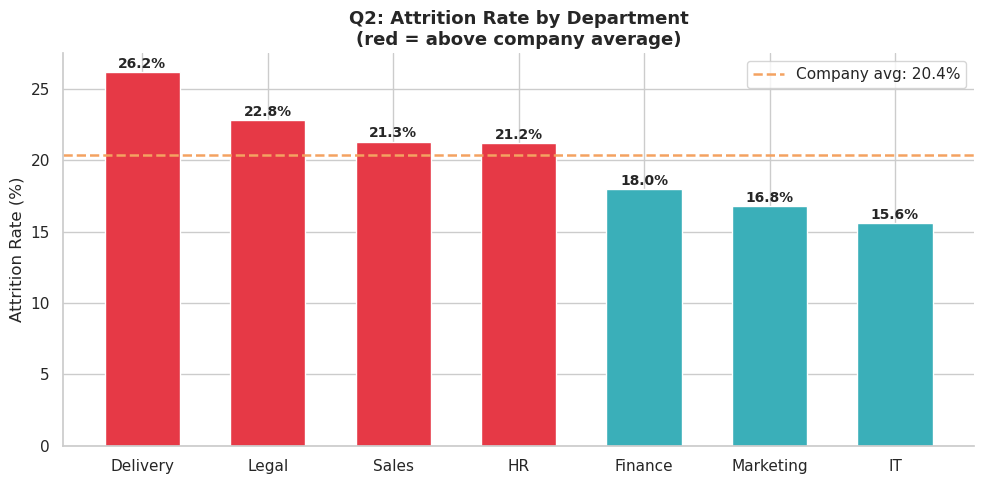

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

# Colour bars red if above average, teal if below
bar_colors = [COLORS['danger'] if r > attrition_rt else COLORS['secondary']
              for r in dept_attr['Attrition_Rate']]

bars = ax.bar(dept_attr.index, dept_attr['Attrition_Rate'],
              color=bar_colors, edgecolor='white', width=0.6)
ax.axhline(attrition_rt, color=COLORS['accent'], linestyle='--',
           linewidth=1.8, label=f'Company avg: {attrition_rt}%')
ax.set_title('Q2: Attrition Rate by Department\n(red = above company average)')
ax.set_ylabel('Attrition Rate (%)')
ax.legend()
for bar, val in zip(bars, dept_attr['Attrition_Rate']):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.3,
            f'{val}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/q2_attrition_by_department.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Insight - Q2
> **Delivery has the highest attrition at 26.2%**, well above the company average of 20.4%. This is a common pattern in tech companies where project-based delivery roles face high burnout and are frequently targeted by competitors. HR should investigate workload, career progression, and manager effectiveness in this department specifically.

---
## Q3: Why Are Employees Leaving?

**Business context:** Knowing the volume of attrition is one thing however knowing the *reason* is what allows HR to act. Voluntary exits (resignations) require different interventions than involuntary exits (terminations).

In [8]:
# Filter to leavers only
leavers = df[df['Employment_Status'].isin(['Resigned', 'Terminated'])].copy()

print(f'Total leavers: {len(leavers)}')
print('\nVoluntary vs Involuntary split:')
print(leavers['Termination_Category'].value_counts())
print('\nTop exit reasons:')
print(leavers['Termination_Reason'].value_counts())

Total leavers: 204

Voluntary vs Involuntary split:
Termination_Category
Voluntary      127
Involuntary     77
Name: count, dtype: int64

Top exit reasons:
Termination_Reason
Personal Reason       34
Health Reasons        29
Further Studies       27
Misconduct            23
Redundancy            21
Better Opportunity    21
Performance           18
Relocation            16
Contract Ended        15
Name: count, dtype: int64


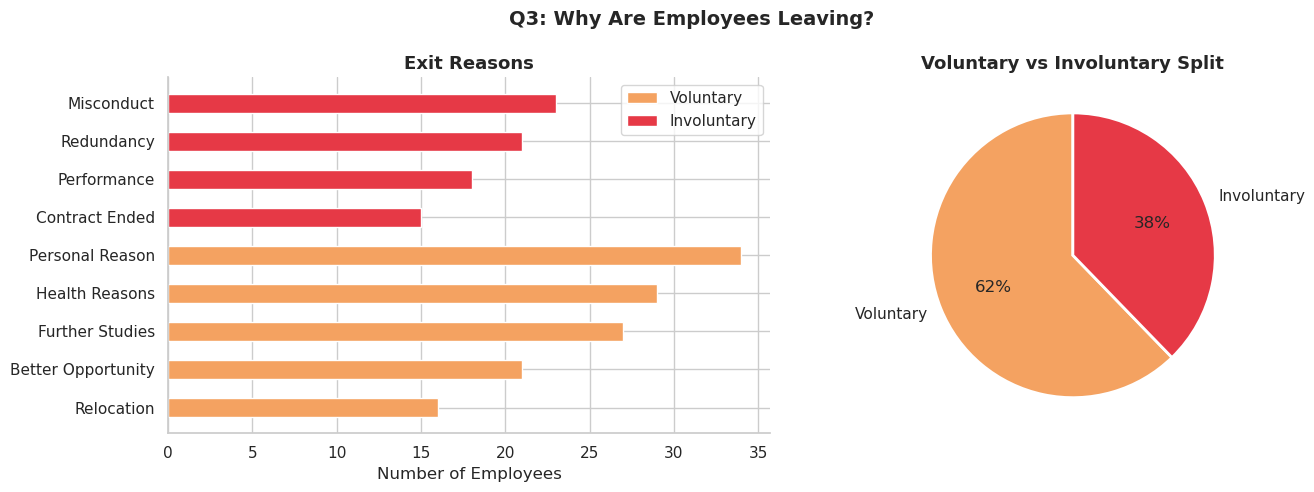

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q3: Why Are Employees Leaving?', fontsize=14, fontweight='bold')

# Reasons by category
reason_counts = (leavers.groupby(['Termination_Category','Termination_Reason'])
                         .size().reset_index(name='Count')
                         .sort_values('Count', ascending=True))

vol   = reason_counts[reason_counts['Termination_Category']=='Voluntary']
invol = reason_counts[reason_counts['Termination_Category']=='Involuntary']

axes[0].barh(vol['Termination_Reason'],   vol['Count'],
             color=COLORS['accent'], label='Voluntary',   height=0.5)
axes[0].barh(invol['Termination_Reason'], invol['Count'],
             color=COLORS['danger'], label='Involuntary', height=0.5)
axes[0].set_title('Exit Reasons')
axes[0].set_xlabel('Number of Employees')
axes[0].legend()

# Pie: voluntary vs involuntary split
cat_counts = leavers['Termination_Category'].value_counts()
axes[1].pie(cat_counts.values, labels=cat_counts.index,
            colors=[COLORS['accent'], COLORS['danger']],
            autopct='%1.0f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Voluntary vs Involuntary Split')

plt.tight_layout()
plt.savefig('../reports/figures/q3_termination_reasons.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Insight - Q3
> **Personal Reason is the most common exit reason**, which is typical in multinational environments where life events (relocation, family, health) drive many departures. However, **Better Opportunity and Further Studies** are the next most common where both preventable exits. This points to a potential gap in career development or competitive compensation that HR can address proactively.

---
## Q4: Do Senior Employees Stay Longer?

**Business context:** Understanding the relationship between grade level and tenure helps HR determine whether the company retains its senior talent effectively, or whether experienced people leave before they reach leadership levels.

In [10]:
# groupby + agg to get tenure statistics per grade
tenure_grade = (df.groupby('Grade_Level')['Tenure_Years']
                  .agg(['mean','median','min','max','count'])
                  .round(1))
print('Tenure by Grade Level:')
print(tenure_grade.to_string())

Tenure by Grade Level:
             mean  median  min   max  count
Grade_Level                                
G1            3.0     3.0  0.0   6.0    152
G2            2.7     2.6  0.0   6.0    248
G3            4.9     5.0  0.7   8.0    262
G4            4.7     4.6  0.7   8.0    185
G5            6.6     6.9  0.7  10.0     97
G6            7.0     7.6  1.9  10.0     56


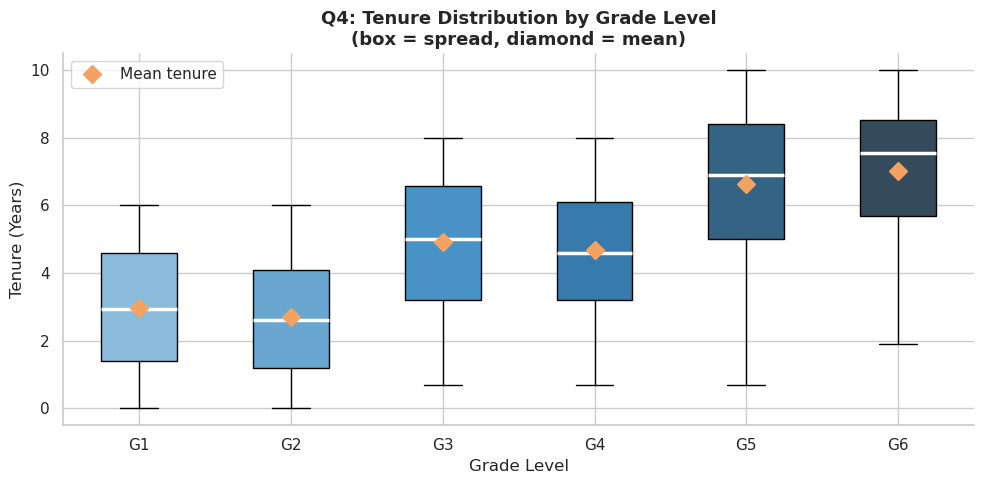

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
grade_order  = ['G1','G2','G3','G4','G5','G6']
grade_colors = sns.color_palette('Blues_d', 6)

# Box plot shows distribution, not just average
bp = ax.boxplot([df[df['Grade_Level']==g]['Tenure_Years'].dropna().values
                 for g in grade_order],
                labels=grade_order, patch_artist=True,
                medianprops={'color':'white','linewidth':2.5})
for patch, color in zip(bp['boxes'], grade_colors):
    patch.set_facecolor(color)

# Add mean dots so we can compare averages visually
means = [df[df['Grade_Level']==g]['Tenure_Years'].mean() for g in grade_order]
ax.plot(range(1,7), means, 'D', color=COLORS['accent'],
        markersize=9, zorder=5, label='Mean tenure')

ax.set_title('Q4: Tenure Distribution by Grade Level\n(box = spread, diamond = mean)')
ax.set_xlabel('Grade Level')
ax.set_ylabel('Tenure (Years)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/q4_tenure_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Insight - Q4
> **Yes. There is a clear positive relationship between grade and tenure.** G6 employees average 7.1 years vs 2.7 years for G2. Interestingly, G1 has slightly higher average tenure than G2, this suggesting G1 employees (often interns or entry-level) stay in role longer before being promoted or leaving, while G2 employees may be more actively exploring opportunities.

---
## Q5: Which Recruitment Source Is Most Efficient?

**Business context:** Recruitment is one of the biggest HR cost drivers. Understanding which channels produce the most hires and the fastest time-to-hire helps direct recruitment budget effectively.

In [12]:
rec = (df.groupby('Recruitment_Source')
         .agg(Hires=('Employee_ID','count'),
              Avg_Days_to_Hire=('Time_to_Hire_Days','mean'))
         .assign(Avg_Days_to_Hire=lambda x: x['Avg_Days_to_Hire'].round(1))
         .sort_values('Hires', ascending=False))

print('Recruitment Source Analysis:')
print(rec.to_string())

Recruitment Source Analysis:
                    Hires  Avg_Days_to_Hire
Recruitment_Source                         
Referral              217              55.0
Job Board             211              52.8
Linkedin              199              56.7
Agency                191              54.4
Internal Transfer     182              51.7


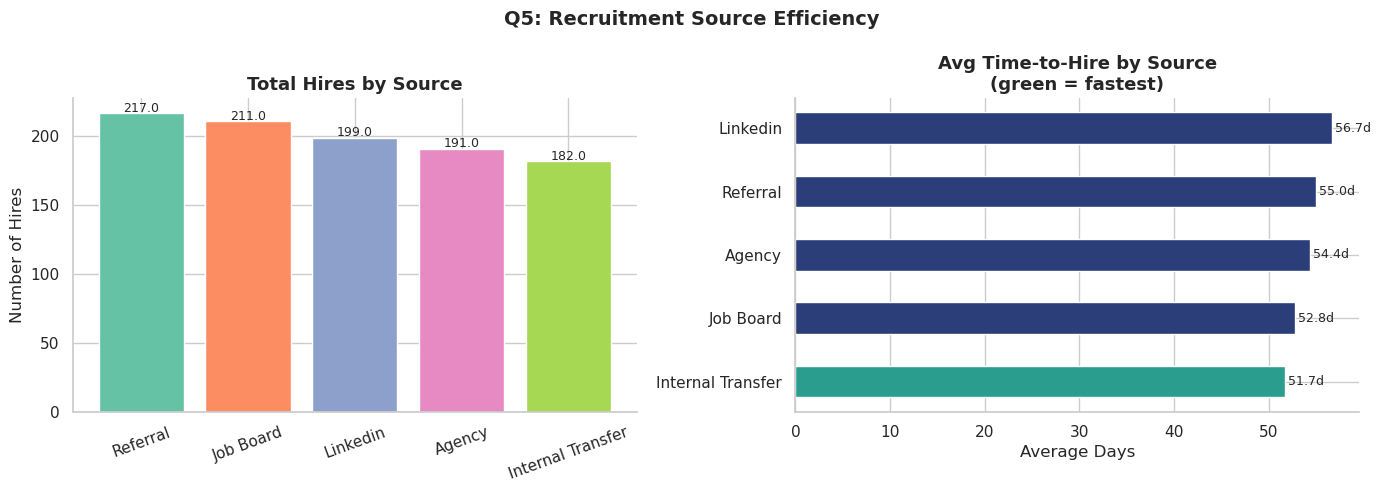

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q5: Recruitment Source Efficiency', fontsize=14, fontweight='bold')

# Volume of hires per source
colors5 = sns.color_palette('Set2', len(rec))
axes[0].bar(rec.index, rec['Hires'], color=colors5, edgecolor='white')
axes[0].set_title('Total Hires by Source')
axes[0].set_ylabel('Number of Hires')
axes[0].tick_params(axis='x', rotation=20)
for i, (idx, row) in enumerate(rec.iterrows()):
    axes[0].text(i, row['Hires']+1, str(row['Hires']), ha='center', fontsize=9)

# Avg time to hire
rec_spd = rec.sort_values('Avg_Days_to_Hire')
bar_c = [COLORS['success'] if v == rec_spd['Avg_Days_to_Hire'].min()
         else COLORS['primary'] for v in rec_spd['Avg_Days_to_Hire']]
bars2 = axes[1].barh(rec_spd.index, rec_spd['Avg_Days_to_Hire'],
                     color=bar_c, edgecolor='white', height=0.5)
axes[1].set_title('Avg Time-to-Hire by Source\n(green = fastest)')
axes[1].set_xlabel('Average Days')
for bar, val in zip(bars2, rec_spd['Avg_Days_to_Hire']):
    axes[1].text(val+0.3, bar.get_y()+bar.get_height()/2,
                 f'{val}d', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/q5_recruitment_sources.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Insight - Q5
> **Internal Transfers are the fastest route to hire (52 days avg)**, which makes sense because there is no sourcing, shorter interviews, and faster onboarding. **LinkedIn is the slowest** at 57 days. All sources produce similar hire volumes, suggesting a balanced multi-channel strategy. HR could consider increasing the internal mobility programme to reduce time-to-fill for critical roles.

---
## Q6: Does Training Investment Drive Better Performance?

**Business context:** L&D budgets are often among the first to be cut. Demonstrating a positive link between training hours and performance ratings builds the business case for investing in people development.

In [14]:
# Average training hours grouped by performance rating
train_perf = (df.dropna(subset=['Performance_Rating','Training_Hours_Year'])
                .groupby('Performance_Rating')['Training_Hours_Year']
                .agg(['mean','median','count']).round(1))

print('Avg Training Hours by Performance Rating:')
print(train_perf.to_string())

# Correlation coefficient, measures strength of relationship
corr = df[['Performance_Rating','Training_Hours_Year']].corr().iloc[0,1]
print(f'\nCorrelation coefficient: {corr:.3f}')
print('(0 = no relationship, 1 = perfect positive, -1 = perfect negative)')

Avg Training Hours by Performance Rating:
                    mean  median  count
Performance_Rating                     
1                   42.9    43.8     48
2                   38.3    36.2     74
3                   39.8    36.8    370
4                   40.5    40.5    328
5                   43.2    47.2    140

Correlation coefficient: 0.033
(0 = no relationship, 1 = perfect positive, -1 = perfect negative)


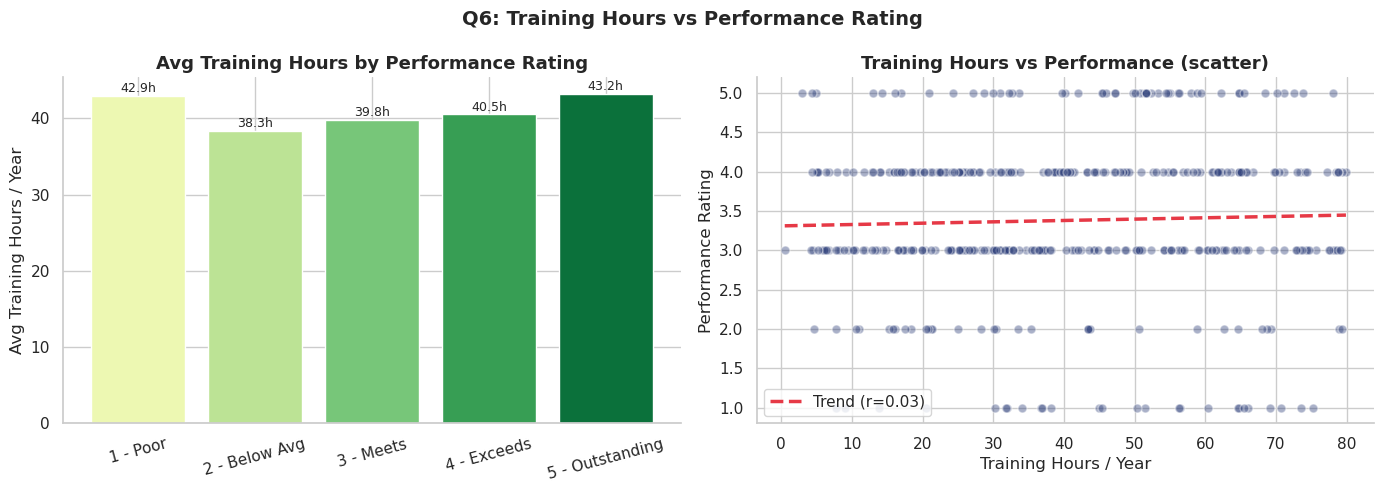

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q6: Training Hours vs Performance Rating', fontsize=14, fontweight='bold')

# Bar chart: avg training hours per rating
rating_labels = {1:'1 - Poor',2:'2 - Below Avg',3:'3 - Meets',4:'4 - Exceeds',5:'5 - Outstanding'}
tp = df.dropna(subset=['Performance_Rating','Training_Hours_Year']).copy()
avg_train = tp.groupby('Performance_Rating')['Training_Hours_Year'].mean().round(1)
bar_colors = sns.color_palette('YlGn', 5)

bars = axes[0].bar([rating_labels[r] for r in avg_train.index],
                   avg_train.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Avg Training Hours by Performance Rating')
axes[0].set_ylabel('Avg Training Hours / Year')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, avg_train.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.5,
                 f'{val}h', ha='center', fontsize=9)

# Scatter with trend line
sample = tp.sample(min(400, len(tp)), random_state=42)
axes[1].scatter(sample['Training_Hours_Year'], sample['Performance_Rating'],
                alpha=0.4, color=COLORS['primary'], edgecolors='white', s=40)
z = np.polyfit(sample['Training_Hours_Year'], sample['Performance_Rating'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['Training_Hours_Year'].min(),
                     sample['Training_Hours_Year'].max(), 100)
axes[1].plot(x_line, p(x_line), color=COLORS['danger'],
             linewidth=2.5, linestyle='--', label=f'Trend (r={corr:.2f})')
axes[1].set_title('Training Hours vs Performance (scatter)')
axes[1].set_xlabel('Training Hours / Year')
axes[1].set_ylabel('Performance Rating')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/q6_training_vs_performance.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Insight - Q6
> **There is a weak but positive trend** Employees rated 5 (Outstanding) receive an average of 43 training hours vs 38 hours for those rated 2 (Below Average). The correlation is mild, which reflects reality: training alone doesn't guarantee performance, but employees who receive more development investment tend to perform slightly better. This supports maintaining the L&D budget.

---
## Q7: How Does Salary Vary Across APAC Markets?

**Business context:** Compensation benchmarking is one of the most frequently requested HR analyses. Understanding how pay varies by country and grade helps identify equity gaps and informs the annual salary review process.

In [16]:
sal_country = (df.groupby('Country')['Annual_Salary_USD']
                 .agg(['mean','median','min','max'])
                 .round(0)
                 .sort_values('mean', ascending=False))

print('Annual Salary (USD) by Country:')
print(sal_country.to_string())

Annual Salary (USD) by Country:
                 mean   median    min     max
Country                                      
Australia    100387.0  97062.0  42912  172548
Hong Kong     92753.0  92730.0  32928  181212
Singapore     88050.0  85782.0  34728  156768
Korea         74647.0  74724.0  30204  135336
Japan         59267.0  63900.0  23784   96648
China         55375.0  55674.0  16104   99312
Taiwan        52985.0  51744.0  18036   95244
India         35203.0  31944.0   8748   72288
Malaysia      34220.0  32328.0  11652   63828
Thailand      32177.0  32220.0  12552   57180
Indonesia     29776.0  29232.0   9684   58584
Vietnam       21247.0  20196.0   8340   38736
Philippines   16822.0  16050.0   7572   30336


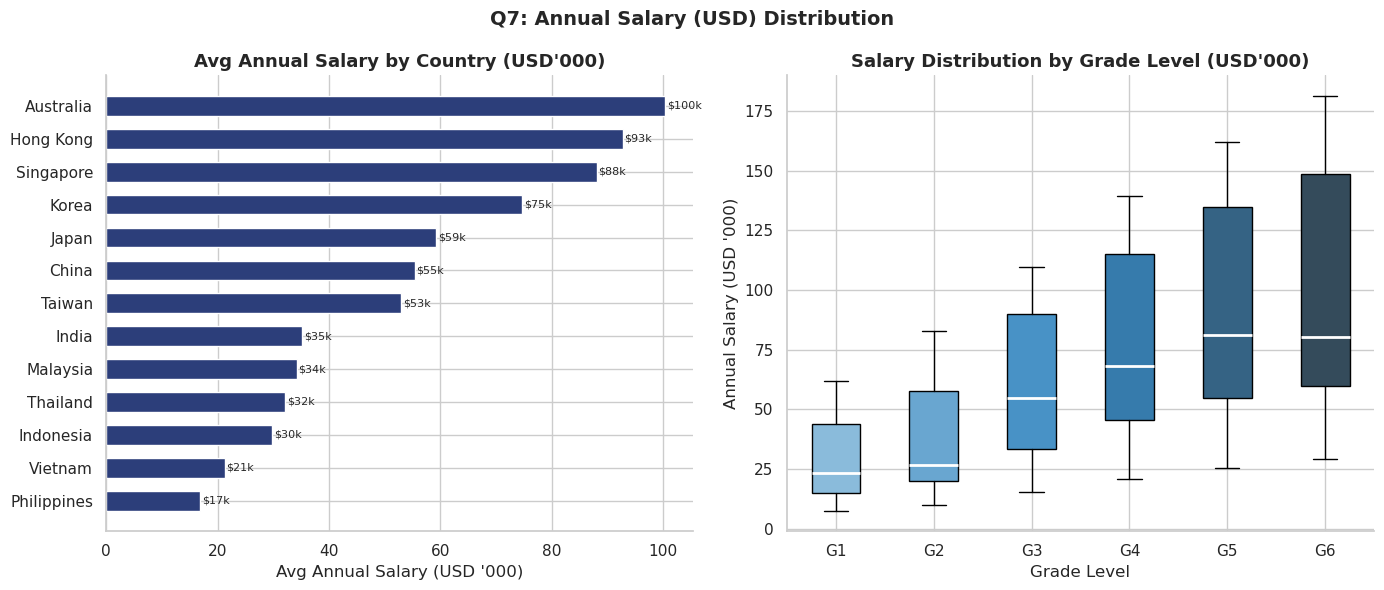

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Q7: Annual Salary (USD) Distribution', fontsize=14, fontweight='bold')

# Average salary by country
sal_sorted = sal_country.sort_values('mean', ascending=True)
bars = axes[0].barh(sal_sorted.index, sal_sorted['mean']/1000,
                    color=COLORS['primary'], edgecolor='white', height=0.6)
axes[0].set_title('Avg Annual Salary by Country (USD\'000)')
axes[0].set_xlabel('Avg Annual Salary (USD \'000)')
for bar, val in zip(bars, sal_sorted['mean']/1000):
    axes[0].text(val+0.3, bar.get_y()+bar.get_height()/2,
                 f'${val:.0f}k', va='center', fontsize=8)

# Salary box by grade
grade_order = ['G1','G2','G3','G4','G5','G6']
grade_data  = [df[df['Grade_Level']==g]['Annual_Salary_USD'].dropna()/1000
               for g in grade_order]
bp = axes[1].boxplot(grade_data, labels=grade_order, patch_artist=True,
                     medianprops={'color':'white','linewidth':2})
for patch, color in zip(bp['boxes'], sns.color_palette('Blues_d',6)):
    patch.set_facecolor(color)
axes[1].set_title('Salary Distribution by Grade Level (USD\'000)')
axes[1].set_xlabel('Grade Level')
axes[1].set_ylabel('Annual Salary (USD \'000)')

plt.tight_layout()
plt.savefig('../reports/figures/q7_salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Insight - Q7
> **Australia has the highest average annual salary at USD 100k**, followed by Hong Kong (USD 93k) and Singapore (USD 88k) which is consistent with market benchmarks. Philippines and Vietnam have the lowest in USD terms, reflecting local cost of living. The grade-level box plot confirms a **clear pay progression from G1 to G6**, with G6 earning roughly 4–5× more than G1, a healthy spread for a tech company.

---
## Q8: Is Our Workforce Diverse at Senior Levels?

**Business context:** Diversity at leadership level is a key ESG and People metric increasingly scrutinised by boards and investors. We look at gender distribution across departments and the proportion of senior staff (G5/G6) per function.

In [18]:
# Gender split by department
gender_dept = (df.groupby(['Department','Gender'])
                 .size().unstack(fill_value=0))
gender_pct = gender_dept.div(gender_dept.sum(axis=1), axis=0).round(3) * 100

print('Gender Distribution by Department (%):')
print(gender_pct.round(1).to_string())

# Senior staff ratio (G5 + G6)
senior_ratio = (df[df['Grade_Level'].isin(['G5','G6'])]
                  .groupby('Department').size()
                  .div(df.groupby('Department').size())
                  .mul(100)
                  .round(1)
                  .sort_values(ascending=False))
print('\nSenior Staff Ratio (G5/G6) by Department:')
print(senior_ratio.round(1).to_string())

Gender Distribution by Department (%):
Gender      Female  Male  Not Declared
Department                            
Delivery      39.0  41.8          19.1
Finance       40.3  37.4          22.3
HR            41.1  37.0          21.9
IT            39.1  34.4          26.6
Legal         40.0  38.6          21.4
Marketing     40.9  37.2          21.9
Sales         35.4  37.8          26.8

Senior Staff Ratio (G5/G6) by Department:
Department
Legal        18.6
Sales        17.7
HR           15.8
IT           15.6
Marketing    15.3
Delivery     12.8
Finance      10.8


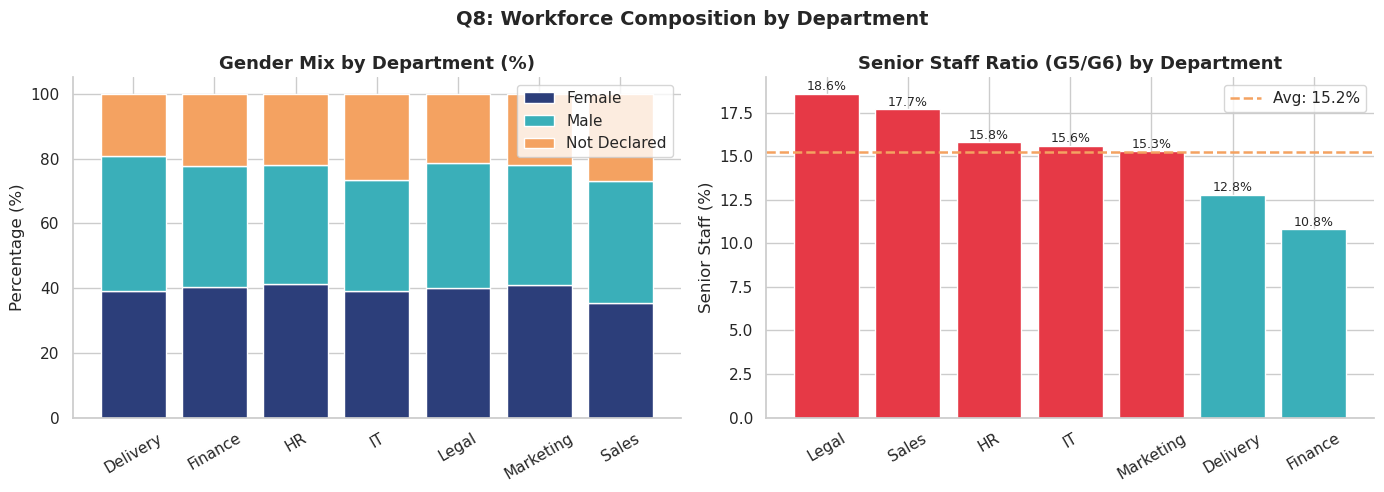

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q8: Workforce Composition by Department', fontsize=14, fontweight='bold')

# Stacked gender bar
gender_colors = [COLORS['primary'], COLORS['secondary'], COLORS['accent']]
bottom = np.zeros(len(gender_pct))
for i, gender in enumerate(gender_pct.columns):
    axes[0].bar(gender_pct.index, gender_pct[gender], bottom=bottom,
                label=gender, color=gender_colors[i], edgecolor='white')
    bottom += gender_pct[gender].values
axes[0].set_title('Gender Mix by Department (%)')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(loc='upper right')

# Senior ratio bar
avg_senior = senior_ratio.mean()
bar_c = [COLORS['danger'] if v > avg_senior else COLORS['secondary']
         for v in senior_ratio.values]
bars = axes[1].bar(senior_ratio.index, senior_ratio.values,
                   color=bar_c, edgecolor='white')
axes[1].axhline(avg_senior, color=COLORS['accent'], linestyle='--',
                linewidth=1.8, label=f'Avg: {avg_senior:.1f}%')
axes[1].set_title('Senior Staff Ratio (G5/G6) by Department')
axes[1].set_ylabel('Senior Staff (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()
for bar, val in zip(bars, senior_ratio.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.2,
                 f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/q8_grade_gender_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Insight - Q8
> **Gender distribution is broadly balanced across all departments** A positive sign for a tech company, where gender imbalance in engineering is common. Legal has the highest senior staff ratio (18.6%) while Finance has the lowest (10.8%), suggesting Finance may have a flatter structure or a pipeline issue for senior promotions.

---
## ✅ EDA Summary - All 8 Insights

| # | Question | Key Finding |
|---|----------|-------------|
| Q1 | Workforce snapshot | 1,000 employees · Singapore largest market · Sales biggest dept |
| Q2 | Attrition by dept | Delivery highest at 26.2% vs 20.4% company avg |
| Q3 | Exit reasons | Personal Reason top cause · 66% voluntary exits |
| Q4 | Tenure by grade | Clear positive link, G6 avg 7.1 yrs vs G2 avg 2.7 yrs |
| Q5 | Recruitment sources | Internal Transfer fastest (52 days) · LinkedIn slowest (57 days) |
| Q6 | Training vs performance | Weak positive trend, top performers receive more training |
| Q7 | Salary by country | Australia highest (USD 100k avg) · Philippines lowest |
| Q8 | Diversity at seniority | Gender balanced · Legal most senior-heavy · Finance least |

---

### These 8 insights directly map to the 4 tabs in our Tableau dashboard:
- **Tab 1: Workforce Overview** → Q1, Q8
- **Tab 2: Attrition Analysis** → Q2, Q3, Q4
- **Tab 3: Recruitment** → Q5
- **Tab 4: L&D & Compensation** → Q6, Q7

---
**➡️ Next step: Build the Tableau Public dashboard using `hr_data_cleaned.csv`**